## Clase n° 4 del curso de ML Transformación de los datos

### Proceso de transformación
- Datos crudos
- Transformación
- Datos preparados
- Modelo entrenado

#### Ingenieria de caracteristicas // Feature Engineering
- Creación: Generar nuevas variables a partir de otras.
- Eliminación: Descartar variables que no son de interés.
- Selección: Elegir las variables mas relevantes
- Transformación: Modificar variables para mejroar su utilidad

##### **Mensaje**: no es solo elegir el mejor modelo, sino que las variables tambien son importante para que el modelo nos den bien.


Deteccion de outliers
- Visualizacion:boxplots, histogramas o diagramas de dispersion
- Metodos estadísticos: se puede considerar con estea a +- 3sd o usar rango intercuartilico.
- Detección automatico

### Entrenamiento vs Testeo

#### Regresion lineal simple / multiple
- Permiten predecir valores numericos continuos
- 

In [1]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
print ("librerias ok")

librerias ok


d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

100%|██████████| 34.1k/34.1k [00:00<00:00, 410kB/s]

Extracting files...
Path to competition files: C:\Users\Josefina Urquiza\.cache\kagglehub\competitions\titanic


In [2]:

# El link se saca de lo que me dice kaggle antes
df_test = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Test.csv")
df_train = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/competitions/titanic/Train.csv")
#Unimos los dos dataset
df_concat = pd.concat([df_train, df_test], ignore_index=True)
#Verificamos
print(f"Hay {len(df_test)} registros en test")
print(f"Hay {len(df_train)} registros en train")
print(f"Hay {len(df_concat)} registros en total")

Hay 418 registros en test
Hay 891 registros en train
Hay 1309 registros en total


In [3]:
# Objetivo predecir el precio del pasaje
df = df_concat.copy()
df.columns
# Hago un encoding para que sean valores unitarios
df['Sex_encoded'] = df['Sex'].map ({"male":0, "female":1})
columas = ['Fare', 'Pclass',  'Sex_encoded', 'Age', 'SibSp', 'Parch']
df = df[columas].dropna()

#Variables que voy a usar para predecir el precio del pasaje
X = df[['Pclass','Sex_encoded', 'Age', 'SibSp', 'Parch']]

#Variable objetivo
Y = df [['Fare']] 

#Cantidad de registreos
print(f"Quedaron {len(df)} pasajeros para el entrenamiento del modelo")

Quedaron 1045 pasajeros para el entrenamiento del modelo


In [5]:
#Ahora si vamos a dividir
# Entrenamiento 80% - 20% testeo
# random_state, es una semilla aleatorio
X_Train,X_Test, Y_Train,Y_Test = train_test_split(X,Y, test_size=0.2, random_state=42)

#Veo la longitud
print(f"Datos para entrenar {X_Train.shape[0]} pasajeros")
print(f"Datos para testear {X_Test.shape[0]} pasajeros")

Datos para entrenar 836 pasajeros
Datos para testear 209 pasajeros


In [6]:
#Entrenar modelo
#Genero el modelo
modelo = LinearRegression ()

#Entreno el modelo con mis datos
modelo.fit(X_Train, Y_Train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# Ahora hay que hacer la prediccion porque el modelo ya esta entrenado
predicciones_train = modelo.predict(X_Train) #visto por el modelo original
predicciones_test = modelo.predict(X_Test) #no visto por el modelo original

In [8]:
# Calculamos metricas estadisticas
#Se calcula el Error Absoluto Medio
mae_train = mean_absolute_error (Y_Train, predicciones_train)
mae_test = mean_absolute_error (Y_Test, predicciones_test)

#Calcular r2 (que porcentaje del problema se entendio)
r2_train = r2_score(Y_Train, predicciones_train)
r2_test = r2_score(Y_Test, predicciones_test)


#Calcular RMSE: con la raiz cuadrada del MSE
rmse_train =np.sqrt(mean_squared_error(Y_Train, predicciones_train))
rmse_test =np.sqrt(mean_squared_error(Y_Test, predicciones_test))


### Hacer print para ver las metricas
print(f"Error promedio del train: {round(mae_train,2)}") # se esta equivocando el boleto en $24.3
print(f"Error promedio del test: {round(mae_test,2)}") # se esta equivocando el boleto en $24.85

#Error cuadtatico medio. En general tiene que dar mas grande
print(f"RMSE train: {round(rmse_train,2)}") # se esta equivocando el boleto en $43.45
print(f"RMSE test: {round(rmse_test,2)}")  # se esta equivocando el boleto en $45.3, el modelo esta pifiando bastante


print(f"R2 train: {round(r2_train,2)}")
print(f"R2 test: {round(r2_test,2)}")



Error promedio del train: 24.3
Error promedio del test: 24.85
RMSE train: 43.45
RMSE test: 45.3
R2 train: 0.39
R2 test: 0.34


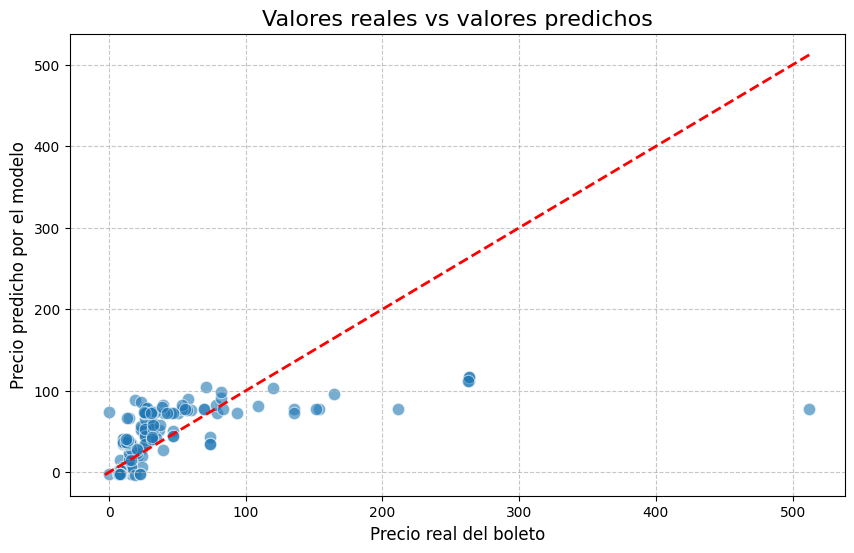

In [9]:
# =============================================================================
# Gráfico de evaluación del modelo: valores reales vs valores predichos
# =============================================================================
# Este gráfico permite evaluar visualmente el desempeño del modelo de regresión.
# Cada punto representa una observación del conjunto de prueba.
# Cuanto más cerca se encuentren los puntos de la línea diagonal (y = x),
# menor será el error de predicción.


# Convertir las estructuras de datos a vectores unidimensionales para facilitar
# su visualización.
y_real = Y_Test.squeeze()
y_pred = predicciones_test.flatten()

# Plot
plt.figure(figsize=(10, 6))

#Valores reales VS los valores predichos
sns.scatterplot(
    x=y_real,
    y=y_pred,
    alpha=0.6,  # Transparencia para mejorar la visualización
    s=80        # Tamaño de los puntos
)

# Calcular los límites del gráfico considerando ambos conjuntos de datos.
# Esto garantiza que la línea de referencia cubra todo el rango observado.
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())

# Dibujar la línea de referencia 1:1
# Los puntos ubicados sobre esta línea representan predicciones exactas.
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2
)

# Configuración estética del gráfico
plt.title("Valores reales vs valores predichos", fontsize=16)
plt.xlabel("Precio real del boleto", fontsize=12)
plt.ylabel("Precio predicho por el modelo", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()